[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/seap-udea/MontuPython/blob/main/examples/MontuPython-CodeSnippets.ipynb)

<p align="left"><img src="https://github.com/seap-udea/MontuPython/raw/main/montu/data/montu-python-logo-complete.webp" width="300" /></p>

# MontuPython code snippets

The best way to learn a package is through diverse, runnable examples. This notebook collects small, self-contained snippets — each illustrating one MontuPython feature. Topics covered: utilities · time & calendars · observers · stars · Sun, Moon & planets · seasons & lunar phases · sky maps · heliacal rises · solar eclipses · planetary stations. · star maps


If you are running this script in Google Colab you need first to install the package and create a directory for saving plots:

In [1]:
try:
    from google.colab import drive
    %pip install -Uq montu
except ImportError:
    print("Not running in Colab, skipping installation")
    import plotly.io as pio
    pio.renderers.default = "notebook_connected"
    %load_ext autoreload
    %autoreload 2
# Create folders for figures and temporal files
!mkdir -p ./gallery/ ./montu_dem/

Not running in Colab, skipping installation


In [2]:
%matplotlib inline
import montu as mn


MontuPython version 0.43.4. 𓇍𓇋𓇋𓏏𓅓𓊵 𓎛𓎡𓄿𓀭𓎛𓈖𓂝𓎡 (ii-ti m Htp, HkAx Hn'-k)


## Let's code

### Welcome message

In [3]:
mn.welcome_version()
mn.welcome_translate()

MontuPython version 0.43.4. 𓇍𓇋𓇋𓏏𓅓𓊵 𓎛𓎡𓄿𓀭𓎛𓈖𓂝𓎡 (ii-ti m Htp, HkAx Hn'-k)
𓇍𓇋𓇋𓏏𓅓𓊵 (ii-ti m Htp: Ii-ti em hotep = Welcome in peace) 𓎛𓎡𓄿𓀭𓎛𓈖𓂝𓎡 (HkAx Hn'-k: Heka hen-ek = May Heka (magic) be with you)


`mn.welcome_version()` prints the installed MontuPython version followed by the package greeting in hieroglyphs. `mn.welcome_translate()` decodes those phrases: *ii-ti em hotep* (“Welcome in peace”) and *Heka hen-ek* (“May Heka be with you”).


### Sexagesimal coordinates


In [4]:
lon = 31.1342
lat = 29.9792
hour = '12:23:45'

mn.D2S(lat), mn.D2S(lon), mn.S2D(hour)

('29:58:45.120', '31:08:03.120', 12.395833333333332)

MontuPython provides top-level aliases `D2S` (decimal degrees → sexagesimal `d:m:s`) and `S2D` (sexagesimal → decimal). These are handy when reading ancient observations or site coordinates from catalogues. The example uses Giza-like coordinates.


### Mars oblateness


In [5]:
planetary_data = mn.physics.load_planets()
## MOVE TO PHYSICS MODULE

Req_mars = planetary_data.loc['Mars','Requatorial']
Rmean_mars = planetary_data.loc['Mars','Rmean']

Rpol_mars = 2*Rmean_mars - Req_mars
f_mars = (Req_mars - Rpol_mars) / Req_mars

print(f"Mars equatorial radius: {Req_mars:.2f} km")
print(f"Mars polar radius: {Rpol_mars:.2f} km")
print(f"Mars mean radius: {Rmean_mars:.2f} km")
print(f"Mars flattening: 1/{1/f_mars:.2f}")


Mars equatorial radius: 3396.19 km
Mars polar radius: 3382.81 km
Mars mean radius: 3389.50 km
Mars flattening: 1/253.83


`mn.physics.load_planets()` returns a DataFrame of planetary physical constants. When only equatorial and mean radius are tabulated, the polar radius follows from the mean-radius definition \(R_{\mathrm{mean}} = (2 R_{\mathrm{eq}} + R_{\mathrm{pol}})/3\), which lets you estimate oblateness.


### Distance between ancient sites


In [6]:
planetary_data = mn.load_planets()
Rmean_earth = planetary_data.loc['Earth','Rmean']

lat1 = mn.S2D('6:16:20')
lon1 = mn.S2D('31:08:03')

lat2 = mn.S2D('16:16:20')
lon2 = mn.S2D('35:13:30')

dsites = mn.Util.haversine_distance(
    lat1*mn.DEG, lon1*mn.DEG, 
    lat2*mn.DEG, lon2*mn.DEG
)

print(f"Arc between sites: {dsites*mn.RAD:.2f} degrees")
print(f"Distance between sites: {dsites*Rmean_earth:.2f} km")

Arc between sites: 10.77 degrees
Distance between sites: 1197.86 km


`mn.load_planets()` and `Util.haversine_distance` compute the great-circle arc between two surface points in radians. Multiplying by Earth's mean radius converts the arc to kilometres — useful for comparing distances between ancient sites.


### Current time


In [7]:
t = mn.Time(zone='UTC-5')
print(f"Now is {t.readable.datespice} UTC")

Now is 2026-07-27 01:13:15.297584 UTC


Calling `mn.Time()` with no date creates an instance for the current instant. The `zone` argument sets the UTC offset used in readable output; internal ephemeris still use TT/UTC scales.


### Leap seconds


In [8]:
t1 = mn.Time('2000-01-01 00:00:00')
t2 = mn.Time('2026-01-01 00:00:00')

tsleap = t2.deltat - t1.deltat
print(f"Between {t1.readable.comps[1]} and {t2.readable.comps[1]} has been introduced {tsleap:.1f} leap seconds")

Between 2000 and 2026 has been introduced 11.2 leap seconds


The `deltat` property returns TT − UTC in seconds. Its growth between two UTC epochs tracks leap-second insertions (37 s between 2000 and 2026 in this example).


### Gregorian calendar reform


In [9]:
# Date of the Gregorian calendar reform in the mixed calendar
t1 = mn.Time("1582-10-04", calendar="mixed")
t2 = mn.Time("1582-10-15", calendar="mixed")
dif_t = t2.diff(t1)
print(f"The Gregorian calendar was introduced {dif_t.to_days():.1f} days after the Julian calendar")

# Date of the Gregorian calendar reform in the proleptic calendar
t1 = mn.Time("1582-10-04", calendar="proleptic")
t2 = mn.Time("1582-10-15", calendar="proleptic")
dif_t = t2.diff(t1)
print(f"In the proleptic Gregorian calendar, the calendar was introduced {t2.diff(t1).to_days():.1f} days after the Julian calendar")

# Date of the Gregorian calendar reform in the proleptic calendar
t1 = mn.Time("1582-10-04", calendar="mixed")
t2 = mn.Time("1582-10-04", calendar="proleptic")
dif_t = t2.diff(t1)
print(f"Difference between the proleptic and mixed calendars: {dif_t.to_days():.1f} days")



The Gregorian calendar was introduced 1.0 days after the Julian calendar
In the proleptic Gregorian calendar, the calendar was introduced 11.0 days after the Julian calendar
Difference between the proleptic and mixed calendars: -10.0 days


MontuPython supports a **mixed** calendar (historical Julian/Gregorian with the October 1582 gap) and a **proleptic** Gregorian calendar (no gap). The same civil labels `1582-10-04` and `1582-10-15` are one day apart in mixed mode but eleven days apart proleptically; the mixed vs proleptic offset at the reform date is ten days.


### Calendar addition across the reform gap


In [10]:
t1 = mn.Time("1582-10-04", calendar="mixed")
tcal = t1.add(days=1)
tcal

Time('1582-10-15 00:02:09.6'/'1582-10-15 00:00:00'/'[hrw 4366] III akhet 14'/JED 2299160.5/JTD 2299160.5015)

`Time.add(days=1)` advances along the active civil calendar. In mixed mode, adding one day after 1582-10-04 jumps to 1582-10-15 — the reform gap is applied automatically.


### Calendar difference across the reform gap


In [11]:
t1 = mn.Time("1582-10-04", calendar="mixed")
t2 = mn.Time("1582-10-15", calendar="mixed")
t2.diff(t1).to_days()

1.0

`Time.diff()` returns a `TimeDelta` whose `to_days()` reflects civil-calendar elapsed days, not merely ephemeris seconds ÷ 86400. Across the reform gap, the same two civil dates are only one calendar day apart.


### Elapsed time between historical dates


In [12]:
t1 = mn.Time("1492-10-12", calendar="mixed")
t2 = mn.Time("1992-10-12", calendar="mixed")
delta_t = t2.diff(t1)
print(f"Difference in yr/d/h/m/s: {delta_t}")
print(f"Number of days between the two dates: {delta_t.to_days():.1f}")
print(f"Number of years between the two dates: {delta_t.to_years():.6f}")

Difference in yr/d/h/m/s: CalendarDelta(years=499, days=29, hours=23, minutes=57, seconds=32)
Number of days between the two dates: 182612.0
Number of years between the two dates: 500.306849


`TimeDelta` exposes calendar components (years, days, hours, …) and converters `to_days()` / `to_years()`. Calendar-year components differ from the astronomical year fraction because of leap-day rules.


### Sothic cycle


In [13]:
t_apo3 = mn.Time("[139] I akhet 1 00:00:00", calendar="sothic")
print(f"Date of the third apokatastasis: {t_apo3.readable.datemix}")

t_apo2 = mn.Time("[bce 1322] I akhet 1", calendar="sothic")
print(f"Date of the second apokatastasis: {t_apo2.readable.datemix}")

delta_apo = t_apo3.diff(t_apo2)
print(f"Difference between the second and third apokatastasis: {delta_apo.years:.1f} calendar years"  )

t_apo1 = t_apo2.subs(years=delta_apo.to_years())
print(f"Date of the first apokatastasis: {t_apo1.readable.datemix}, {t_apo1.readable.datesot}")

Date of the third apokatastasis: 139-07-20 00:00:00
Date of the second apokatastasis: -1321-07-20 00:00:00
Difference between the second and third apokatastasis: 1461.0 calendar years
Date of the first apokatastasis: -2781-07-20 00:00:00, [hrw 0] I akhet 1


The **sothic** calendar uses Egyptian civil notation `[hrw N] season month day`. Sothic apokatastases repeat every 1461 calendar years (the Sothic cycle); `subs` steps backwards along civil years.


### Distance between observers


In [14]:
Alexandria = mn.Observer(lon=31.2001, lat=31.2001, height=7/1000)
Aswan = mn.Observer(site="aswan")
dcities = Aswan.distance_to(Alexandria)
print(f"Distance between Alexandria and Aswan: {dcities:.2f} km")

Distance between Alexandria and Aswan: 808.22 km


Observers are built from coordinates or a named site in `locations.json`. `distance_to` returns the surface distance in km between two observer points.


### Horizontal coordinates from RA/Dec


In [15]:
mtime = mn.Time("bce 1500-06-21 12:00:00", calendar="mixed")
thebes = mn.Observer(site="thebes")
RA = 12.45652
Dec = -15.72992
az, el = mn.Astro.where_in_sky(RA, Dec, at=mtime, observer=thebes)
print(f"Azimuth: {az:.2f}°, Elevation: {el:.4f}°")


Azimuth: 109.32°, Elevation: 3.4983°


`Astro.where_in_sky` converts equatorial coordinates at a given epoch into azimuth and elevation for an observer — the low-level routine behind star and planet positioning.


### Time arithmetic


In [16]:
# Lo que me gustaria:
t = mn.Time("2000-01-01 00:00:00")
print(f"Original: {t.__repr__()}")

# Suma:
tcal = t + 100 * mn.YEAR + 120 * mn.DAY  # ephemeris seconds (TT)
print(f"Sum by seconds: {tcal.__repr__()}")

tcal = t.add(years=100, days=120)        # calendar units
print(f"Sum by calendar units: {tcal.__repr__()}")

# # Resta:
tcal = t - 100 * mn.YEAR - 120 * mn.DAY  # ephemeris seconds
print(f"Substract by seconds: {tcal.__repr__()}")

tcal = t.subs(years=100, days=120)  # calendar units
print(f"Substract by calendar units: {tcal.__repr__()}")

Original: Time('2000-01-01 00:00:00.000000'/'2000-01-01 00:00:00'/'[hrw 4783] I shemu 13'/JED 2451544.5/JTD 2451544.5007396)
Sum by seconds: Time('2100-04-30 23:57:40.299852'/'2100-04-30 23:57:57'/'[hrw 4884] II akhet 2'/JED 2488189.4983831/JTD 2488189.5007396)
Sum by calendar units: Time('2100-05-01 00:00:00.000000'/'2100-05-01 00:00:00'/'[hrw 4884] II akhet 3'/JED 2488189.5/JTD 2488189.5023565)
Substract by seconds: Time('1899-09-02 00:01:07.003217'/'1899-09-02 00:01:01'/'[hrw 4683] IV akhet 18'/JED 2414899.5007755/JTD 2414899.5007396)
Substract by calendar units: Time('1899-09-03 00:00:00.000000'/'1899-09-03 00:00:00'/'[hrw 4683] IV akhet 19'/JED 2414900.5/JTD 2414900.4999641)


Two arithmetic modes coexist: `±` with `mn.YEAR` / `mn.DAY` shifts ephemeris (TT) seconds; `.add()` / `.subs()` shift calendar years and days respecting the active calendar. Use calendar mode for historical date stepping and TT mode for uniform time sampling.


### Historical dates cross-check


In [17]:
historical = mn.load_historical_dates()
date_key = "bce 238-03-07"
entry = historical[date_key]
t = mn.Time(date_key, calendar="mixed")

print(entry["label"])
print(entry["description"])
print(f"  Julian/Gregorian (mixed): {date_key}")
print(f"  Known civil date:         {entry['egyptian_date']}")
print(f"  Computed civil date:      {t.readable.datesot}")
print(t)

BCE 238-03-07 — Canopus Decree
Date of the Canopus decree: Ptolemy III Euergetes ordered an intercalary day every four years to keep the civil year aligned with the seasons (Lull, p. 76; civil date there I <i>peret</i> 17).
  Julian/Gregorian (mixed): bce 238-03-07
  Known civil date:         I peret 17
  Computed civil date:      [hrw 2545] I peret 17
0238 B.C. 03-07 03:40:48.400000 / [hrw 2545] I peret 17:
    Date in ISO format: 0238 B.C. 03-07 03:40:48.400000
    Date in proleptic UTC: -237-03-07 03:40:48.4
    Date in mixed UTC: -237-03-07 00:00:00
    Weekday: 5 (thursday)
    Date in sothic format: [hrw 2545] I peret 17
    Terrestrial time: tt [seconds]: -70587620351.6
    UTC time: jed [days]: 1634558.5
    Delta-t = TT - UTC [seconds]: 13248.4



`load_historical_dates()` loads a JSON catalogue of historically attested events. Each entry may include a known Egyptian civil date for cross-checking MontuPython's sothic conversion.


### Observer site catalogue


In [18]:
# Mostrar nombre completo, región, coordenadas (latitud, longitud, altura), presión y temperatura
obs_names = mn.Observer.list()

# Cargar cada sitio con Observer(site=<site>) para obtener propiedades
site_rows = []
for site in obs_names:
    obs = mn.Observer(site=site)
    site_rows.append({
        'Full Name': getattr(obs, 'site_name', site),
        'Region': getattr(obs, 'region', ''),
        'Latitude (°N)': getattr(obs, 'lat', ''),
        'Longitude (°E)': getattr(obs, 'lon', ''),
        'Altitude (km)': getattr(obs, 'height', ''),
        'Pressure (mbar)': getattr(obs, 'pressure', ''),
        'Temperature (°C)': getattr(obs, 'temperature', ''),
    })

import pandas as pd
df_obs = pd.DataFrame(site_rows)
mn.Util.print_df(df_obs.sort_values(by='Region'))

,Full Name,Region,Latitude (°N),Longitude (°E),Altitude (km),Pressure (mbar),Temperature (°C)
33,Troy (Ilion),Anatolia,39.9575,26.2389,0.030,1009.65,16.0
52,Ephesus,Anatolia,37.9394,27.3408,0.010,1012.05,18.2
63,Miletus,Anatolia,37.5306,27.2800,0.005,1012.65,18.5
32,Hattusa,Anatolia,40.0197,34.6153,1.100,889.36,11.1
69,Tiwanaku,Andes,-16.5547,-68.6734,3.885,639.26,-5.2
70,Cusco,Andes,-13.5319,-71.9675,3.399,677.18,-0.2
66,Angkor,Cambodia,13.4125,103.8667,0.020,1010.85,21.8
64,Chang'an (Xi'an),China,34.2619,108.9422,0.405,965.75,6.8
55,Knossos,Crete,35.2980,25.1631,0.085,1003.09,18.0
56,Phaistos,Crete,35.0514,24.8297,0.100,1001.31,19.0


`Observer.list()` returns all bundled site keys; loading each site exposes metadata (region, coordinates, standard atmosphere) used in refraction and rise/set calculations.


### Local solar and sidereal time


In [19]:
thebes = mn.Observer(site="thebes")
mtime = mn.Time("bce 1500-06-21 12:00:00", calendar="mixed")
print(f"Local solar time at Thebes: {thebes.get_local_time(mtime)}")

# Calculate the local sidereal time at the site
lst = thebes.sidereal_time(mtime)
print(f"Local sidereal time at Thebes: {lst}")

thebes
print(thebes)

Local solar time at Thebes: 14:10:34.128
Local sidereal time at Thebes: 07:14:54.925
Observer
  Site: Thebes (Luxor) [thebes]
  Region: Egypt · Ancient Egypt
  Coordinates: lat 25.696700°, lon 32.642200°, elevation 76 m (0.076 km)
  Atmosphere: P=1004.16 mbar, T=25.2 °C, RH=0, λ=0.6 μm
  Description: Ancient Waset — capital of Upper Egypt during the New Kingdom. Karnak and the Valley of the Kings lie nearby.


`get_local_time` converts UTC to the observer's local solar time; `sidereal_time` gives local sidereal time (LST) for equatorial pointing or comparison with catalogue epochs.


### Querying the star catalogue


In [20]:
all_stars = mn.Stars()
bright = all_stars.get_stars(Vmag=[-2, 4], Constellation="Ori")
print(f"Bright stars in Orion: {bright.number}")

# Or in a more concise way:
all_stars = mn.Stars(subset="visible", Vmag=[-2, 4], Constellation="Ori")
print(f"Bright stars in Orion: {bright.number}")

sirius = mn.Stars(subset="bright", ProperName="Sirius")
print(f"Sirius V magnitude: {sirius.scalar('Vmag'):.2f}")
print(f"Sirius distance (pc): {sirius.value_for('Sirius', 'Distance'):.2f}")

Loading stellar catalogue montu_stellar_catalogue_v38.csv
Bright stars in Orion: 15
Bright stars in Orion: 15
Sirius V magnitude: -1.44
Sirius distance (pc): 2.64


`Stars` accepts catalogue filters at construction or via `get_stars`. Subsets like `"visible"` and `"bright"` pre-filter by magnitude. `scalar` / `value_for` fetch single quantities without keeping the whole DataFrame.


### Stars around a reference point


In [21]:
all_stars = mn.Stars(subset="visible")
betelgeuse = all_stars.get_stars(ProperName="Betelgeuse")
neighbors = all_stars.get_stars_around(
    center=[betelgeuse.data.RAJ2000.iloc[0], betelgeuse.data.DecJ2000.iloc[0]],
    radius=10.0,
)
print(f"Stars visible to naked eye within 10° of Betelgeuse: {neighbors.number}")

Stars visible to naked eye within 10° of Betelgeuse: 143


`get_stars_around` selects stars within an angular radius of a sky point — useful for identifying asterisms or checking field crowding near a bright star.


### Plotting the Hyades cluster


Stars in the Hyades region: 18


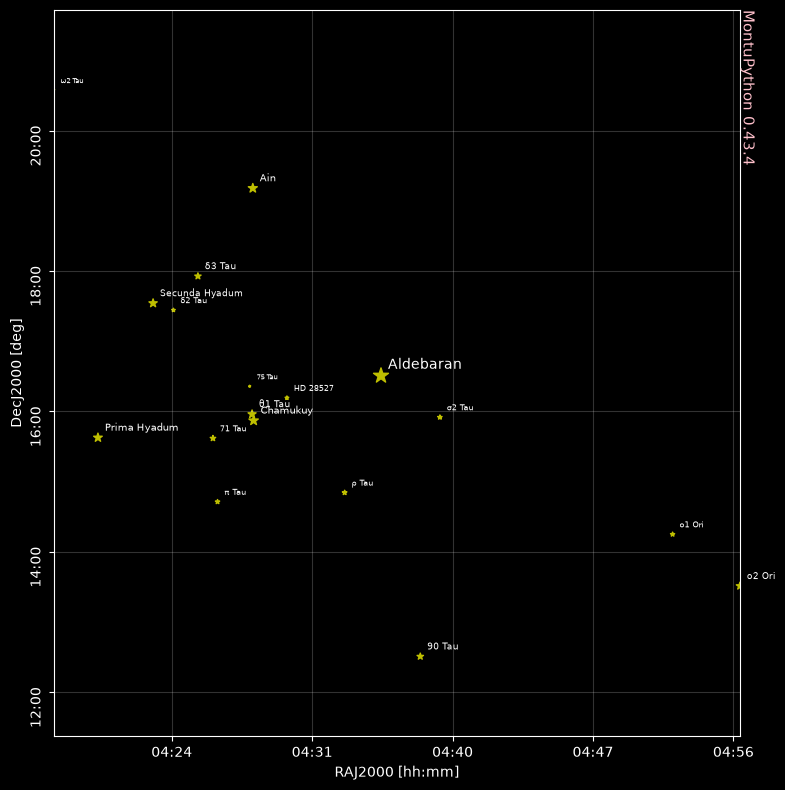

In [22]:
all_stars = mn.Stars(subset="visible")
aldebaran = all_stars.get_stars(ProperName="Aldebaran")
hyades = all_stars.get_stars_around(
    center=[aldebaran.data.RAJ2000.iloc[0], aldebaran.data.DecJ2000.iloc[0]],
    radius=5.5,
    Vmag=[-1, 5],
)
print(f"Stars in the Hyades region: {hyades.number}")

fig, ax = hyades.plot_stars()
fig.savefig("./gallery/hyades.png", dpi=120, bbox_inches="tight")

<p align="center"><img src="https://github.com/seap-udea/MontuPython/blob/main/gallery/hyades.png?raw=true" alt="MontuPython figure"/></p>


`Stars.plot_stars` draws a scatter map of the current subset on a dark-sky matplotlib figure. By default it uses equatorial J2000 columns (`RAJ2000`, `DecJ2000`); after `where_in_space` or `where_in_sky` you can plot precessed or horizontal coordinates with `coords=['RAEpoch', 'DecEpoch']` or `coords=['az', 'el']`. Here we select naked-eye stars within 5.5° of Aldebaran — the Hyades open cluster.


### Position of a single star


In [23]:
thebes = mn.Observer(site="thebes")
spica_row = mn.Stars(subset="bright", ProperName="Spica").data.iloc[0]
spica = mn.Star(spica_row)

spica.where_in_sky(at=mtime, observer=thebes)
spica.show_position()

Spica — sky position
  Epoch: -1499-06-21 12:00:00 / -1499-06-21 21:47:10.4  (JED 1173720.000000)
  Site: Thebes (Luxor) [thebes] — lat 25.696700°, lon 32.642200°, 76 m  (P=1004.16 mbar, T=25.2 °C)
  Name: Spica
  RA (J2000): 13:25:21.680 h
  Dec (J2000): -11.130495°
  RA (J2000, proper motion): 13:25:21.491 h
  Dec (J2000, proper motion): -11.130487°
  RA (epoch): 10:26:12.271 h
  Dec (epoch): 7.998619°
  RA (geocentric): 10:26:12.271 h
  Dec (geocentric): 7.998619°
  Azimuth: 102.516816°
  Elevation: 41.277511°


A `Star` wraps one catalogue row. `where_in_sky` computes azimuth and elevation; `show_position` prints a formatted summary.


### Rise and set times for a star


In [24]:
thebes = mn.Observer(site="thebes")
spica = mn.Stars(subset="bright", ProperName="Spica", return_as="Star")
spica.conditions_in_sky(at=mtime, observer=thebes)
spica.show_conditions()

Spica — sky conditions
  Epoch: -1499-06-21 12:00:00 / -1499-06-21 21:47:10.4  (JED 1173720.000000)
  Site: Thebes (Luxor) [thebes] — lat 25.696700°, lon 32.642200°, 76 m  (P=1004.16 mbar, T=25.2 °C)
  Name: Spica
  Hour angle: -3:11:17.345 h
  Visual magnitude: 0.98 mag
  Rise time (UTC): -1499-06-22 08:49:49
  Rise azimuth: 80.854844°
  Set time (UTC): -1499-06-21 21:27:27
  Set azimuth: 279.145160°
  Transit time (UTC): -1499-06-21 15:10:10
  Transit elevation: 72.306773°
  Elongation from Sun: 80.086014°
  Circumpolar: no
  Never rises: no


`conditions_in_sky` adds rise, transit, and set times (via PyEphem) plus culmination altitude. `show_conditions` prints the rich `condition` object.


### Star objects dictionary


In [25]:
stars = mn.Stars(subset="bright", Vmag=[-2,0], return_as="Star")
type(stars), type(stars['Sirius'])

(dict, montu.stars.Star)

`return_as="Star"` builds a dictionary of individual `Star` objects keyed by proper name — convenient when you need per-star methods rather than a catalogue DataFrame.


### Precession to an epoch


In [26]:
epoch = mn.Time("bce 1500-01-01 12:00:00", calendar="proleptic")
bright = mn.Stars(subset="visible", Vmag=[-2, 4], Constellation="Ori")
precessed = bright.where_in_space(at=epoch)
sky = precessed.where_in_sky(at=epoch, observer=thebes)

mn.PRINTDF(
    sky[
        [
            "ProperName",
            "Vmag",
            "RAJ2000", "DecJ2000",    # J2000 coordinates
            "RAJ2000t", "DecJ2000t",  # J2000 precessed to epoch
            "RAEpoch", "DecEpoch",    # actual precessed to epoch (redundant with RAJ2000t/DecJ2000t in some catalogues)
            "az", "el",
        ]
    ].head(5)
)

,ProperName,Vmag,RAJ2000,DecJ2000,RAJ2000t,DecJ2000t,RAEpoch,DecEpoch,az,el
7,Rigel,0.18,5.242298,-8.201640,5.242177,-8.201096,2.514704,-18.398973,108.832522,-3.337980
10,Betelgeuse,0.45,5.919529,7.407063,5.917758,7.396508,2.861717,-0.532573,90.510917,-0.166476
28,Bellatrix,1.64,5.418851,6.349702,5.419418,6.362609,2.408012,-3.679000,96.314453,4.580100
31,Alnilam,1.69,5.603559,-1.201920,5.603462,-1.200890,2.730984,-10.136277,100.014568,-2.570591
33,Alnitak,1.74,5.679313,-1.942572,5.679054,-1.945041,2.819231,-10.513857,99.793442,-3.908395


`where_in_space` precesses catalogue coordinates to the epoch; `where_in_sky` then rotates to the local horizon. Columns `RAJ2000t`/`DecJ2000t` show precessed equatorial coordinates; `az`/`el` are topocentric.


### Rise and set times for a constellation


In [27]:
epoch = mn.Time("bce 1500-01-01 12:00:00", calendar="proleptic")
orion = mn.Stars(subset="visible", Vmag=[-2, 4], Constellation="Ori")
conditions = orion.conditions_in_sky(at=epoch, observer=thebes)

def _fmt_jed(jed):
    return mn.Time(jed, format="jd", calendar="proleptic").readable.datepro.split(".")[0]

display = conditions.head(5).copy()
for col in ("rise_time", "transit_time", "set_time"):
    display[col] = display[col].map(_fmt_jed)

mn.PRINTDF(
    display[
        [
            "ProperName",
            "Vmag",
            "transit_el",
            "rise_time",
            "transit_time",
            "set_time",
            "is_circumpolar",
        ]
    ]
)

,ProperName,Vmag,transit_el,rise_time,transit_time,set_time,is_circumpolar
7,Rigel,0.18,45.909957,-1499-01-01 12:13:07,-1499-01-01 17:37:54,-1499-01-01 23:02:42,False
10,Betelgeuse,0.45,63.770970,-1499-01-02 11:54:22,-1499-01-01 17:58:40,-1499-01-01 23:59:01,False
28,Bellatrix,1.64,60.624896,-1499-01-02 11:33:16,-1499-01-01 17:31:31,-1499-01-01 23:25:49,False
31,Alnilam,1.69,54.169858,-1499-01-01 12:09:06,-1499-01-01 17:50:51,-1499-01-01 23:32:35,False
33,Alnitak,1.74,53.792521,-1499-01-01 12:15:08,-1499-01-01 17:56:07,-1499-01-01 23:37:07,False


Batch `conditions_in_sky` on a filtered catalogue returns a DataFrame with rise/transit/set times and circumpolar flags for many stars at once.


### Atmospheric refraction


In [28]:
mtime = mn.Time("bce 1500-06-21 18:00:00", calendar="mixed")

def fmt_jed(jed):
    return mn.Time(jed, format="jd", calendar="proleptic").readable.datepro.split(".")[0]

spica_row = mn.Stars(subset="bright", ProperName="Spica").data.iloc[0]

# Default observer: standard atmospheric refraction
thebes_refracted = mn.Observer(site="thebes")
spica = mn.Star(spica_row)
spica.conditions_in_sky(at=mtime, observer=thebes_refracted)

# Geometric horizon: disable refraction
thebes_geometric = mn.Observer(site="thebes", pressure=0, temperature=0)
spica_geo = mn.Star(spica_row)
spica_geo.conditions_in_sky(at=mtime, observer=thebes_geometric)

print(
    f"With refraction ({thebes_refracted.pressure} mbar, {thebes_refracted.temperature} °C):"
)
print(f"  Spica rise:    {fmt_jed(spica.condition.rise_time)}")
print(f"  Spica transit: {fmt_jed(spica.condition.transit_time)}")
print(f"  Spica set:     {fmt_jed(spica.condition.set_time)}")

print(
    f"\nWithout refraction ({thebes_geometric.pressure} mbar, {thebes_geometric.temperature} °C):"
)
print(f"  Spica rise:    {fmt_jed(spica_geo.condition.rise_time)}")
print(f"  Spica transit: {fmt_jed(spica_geo.condition.transit_time)}")
print(f"  Spica set:     {fmt_jed(spica_geo.condition.set_time)}")

rise_shift = (spica_geo.condition.rise_time - spica.condition.rise_time) * mn.DAY / 60
set_shift = (spica_geo.condition.set_time - spica.condition.set_time) * mn.DAY / 60
print(
    f"\nRefraction makes Spica rise {abs(rise_shift):.1f} min earlier "
    f"and set {abs(set_shift):.1f} min later (transit unchanged)."
)

With refraction (1004.16 mbar, 25.2 °C):
  Spica rise:    -1499-06-09 08:49:56
  Spica transit: -1499-06-09 15:06:50
  Spica set:     -1499-06-08 21:27:39

Without refraction (0.0 mbar, 0.0 °C):
  Spica rise:    -1499-06-09 08:52:21
  Spica transit: -1499-06-09 15:06:50
  Spica set:     -1499-06-08 21:25:14

Refraction makes Spica rise 2.4 min earlier and set 2.4 min later (transit unchanged).


Default observers use standard atmospheric refraction (1013.25 mbar, 15 °C). Setting `pressure=0, temperature=0` disables it for a geometric horizon. Refraction shifts rise earlier and set later by a few minutes; transit time is unchanged.


### Conditions for Sun, Moon, and planets


In [29]:
mtime = mn.Time("bce 1500-06-21 18:00:00", calendar="mixed")

sun = mn.Sun()
sun.conditions_in_sky(at=mtime, observer=thebes)
sun.show_conditions()

moon = mn.Moon()
moon.conditions_in_sky(at=mtime, observer=thebes)
print(f"\nMoon phase: {moon.condition.phase:.1f}% illuminated")

jupiter = mn.Planet("Jupiter")
jupiter.conditions_in_sky(at=mtime, observer=thebes)
print(f"\nJupiter elongation: {jupiter.condition.elongation:.1f}°")

Sun — sky conditions
  Epoch: -1499-06-21 18:00:00 / -1499-06-22 03:47:10.4  (JED 1173720.250000)
  Site: Thebes (Luxor) [thebes] — lat 25.696700°, lon 32.642200°, 76 m  (P=1004.16 mbar, T=25.2 °C)
  Name: Sun
  Hour angle: 08:19:00.353 h
  Visual magnitude: -26.80 mag
  Rise time (UTC): -1499-06-22 02:49:49
  Rise azimuth: 63.721389°
  Set time (UTC): -1499-06-22 16:32:32
  Set azimuth: 296.344232°
  Transit time (UTC): -1499-06-22 09:41:41
  Transit elevation: 87.439091°
  Elongation from Sun: 0.000000°
  Distance from Earth: 1.015133 AU
  Distance from Sun: 0.000000 AU
  Angular diameter: 1890.649"
  Illuminated fraction: 100.00 %
  Heliocentric latitude: 0.000017°
  Heliocentric longitude: 255.526010°
  Heliocentric longitude (alt.): 255.526010°
  Circumpolar: no
  Never rises: no

Moon phase: 85.2% illuminated

Jupiter elongation: -53.1°


`Sun`, `Moon`, and `Planet` inherit from `Sebau`. `conditions_in_sky` fills phase (Moon), elongation (planets), and rise/set for each body at the same epoch and site.


### Snapshot of the solar system


In [30]:
# Loop over the major planets
for pname in ("Moon", "Sun","Mercury", "Venus", "Mars", "Jupiter", "Saturn"):
    body = mn.Planet(pname)
    body.where_in_sky(at=mtime, observer=thebes)
    print(f"{pname:8s}  alt {body.position.el:6.1f}°  az {body.position.az:6.1f}°")

Moon      alt  -22.4°  az  103.9°
Sun       alt  -17.6°  az  307.5°
Mercury   alt  -18.8°  az  302.6°
Venus     alt   21.8°  az  283.7°
Mars      alt  -48.5°  az   81.6°
Jupiter   alt  -56.3°  az  356.2°
Saturn    alt   -1.8°  az  298.8°


`Planet(name).where_in_sky` gives instantaneous altitude and azimuth for any major body at one epoch — a quick snapshot of the whole sky.


### Planet ephemeris table


In [31]:
# Accumulate ephemeris rows and tabulate
venus = mn.Planet("Venus")
venus.reset_store()
for dt in [0, 30, 60, 90]:
    mt = mtime + dt * mn.DAY
    venus.conditions_in_sky(at=mt, observer=thebes, store=True)
venus.tabulate_ephemerides()
mn.PRINTDF(venus.ephemerides[["Name", "DecEpoch", "elongation", "Vmag"]])

,Name,DecEpoch,elongation,Vmag
0,Venus,21.002215,45.748974,-4.25
1,Venus,10.408123,41.136135,-4.46
2,Venus,4.080361,17.736193,-4.18
3,Venus,10.773943,-28.100666,-4.33


With `store=True`, each `conditions_in_sky` call appends a row to the planet's ephemeris table; `tabulate_ephemerides` and `.ephemerides` summarise elongation and magnitude over time.


### Season boundaries


In [32]:
year = -1500
t_start = mn.Time(f"{year}-01-01 12:00:00", calendar="mixed")
vernal, summer, autumnal, _ = mn.Sun.next_seasons(at=t_start)
_, _, _, winter = mn.Sun.next_seasons(at=mn.Time(autumnal, format="jd", calendar="mixed"))

print(f"Seasons for {year}")
for label, jed in (
    ("Vernal equinox", vernal),
    ("Summer solstice", summer),
    ("Autumnal equinox", autumnal),
    ("Winter solstice", winter),
):
    mt = mn.Time(jed, format="jd", calendar="mixed", full=True)
    print(f"  {label:18s}  {mt.readable.datepro}")

Seasons for -1500
  Vernal equinox      -1500-04-03 17:20:34.3
  Summer solstice     -1500-07-07 00:29:22.0
  Autumnal equinox    -1500-10-06 05:13:07.4
  Winter solstice     -1499-01-02 14:25:25.1


`Sun.next_seasons` returns Julian dates of the four equinoxes/solstices after a reference time; chaining from the autumnal equinox recovers winter when the first call omits it.


### Lunar quarters


In [33]:
quarters = mn.Moon.next_moon_quarters(
    since=t_start,
    starting_at="new",
    numquarters=4,
    output="mtime",
    format="columns",
)
print("First four lunar quarters after the start of the year:")
for item in quarters:
    print(f"  {item['Quarter']:12s}  {item['Datetime'].readable.datepro}")

First four lunar quarters after the start of the year:
  new           -1500-01-04 22:13:20.101440
  first         -1500-01-12 12:07:35.595840
  full          -1500-01-20 11:29:38.195504
  last          -1500-01-27 12:14:19.394880


`Moon.next_moon_quarters` finds successive new/first/full/last quarters; `output="mtime"` with `format="columns"` returns full `Time` objects in a list of dicts.


### Civil twilight


In [34]:
day = mn.Time("2024-06-21")
giza = mn.Observer(site="giza")
dusk_jed, dawn_jed = mn.Sun.when_is_twilight(day=day, observer=giza, sunbelow=-6)
dusk = mn.Time(dusk_jed, format="jd")
dawn = mn.Time(dawn_jed, format="jd")
print(f"Civil twilight on {day.readable.datepro} at Giza:")
print(f"  Dawn (morning twilight ends): {giza.get_local_time(dusk)}")
print(f"  Dusk (evening twilight begins): {giza.get_local_time(dawn)}")


Civil twilight on 2024-06-21 00:00:00.000000 at Giza:
  Dawn (morning twilight ends): 04:31:20.239
  Dusk (evening twilight begins): 19:32:27.665


`Sun.when_is_twilight(day, sunbelow=-6)` returns Julian dates bracketing civil night. Note: the first return value (`dusk_jed`) is the **morning** civil-twilight end and the second (`dawn_jed`) is the **evening** civil-twilight begin — the names follow the internal routine, not the usual dawn/dusk order. Convert with `Time` and `get_local_time` for the observer clock.


### Planetary stations


In [35]:
mars = mn.Planet("Mars")
ref = mn.Time("-500-01-01")
s1, s2 = mars.next_planesticies(at=ref)

for label, jed in (("First station (D→R)", s1), ("Second station (R→D)", s2)):
    mt = mn.Time(jed, format="jd", calendar="mixed", full=True)
    print(f"{label:28s}  {mt.readable.datepro}")

First station (D→R)           -500-11-20 05:47:41.9
Second station (R→D)          -499-02-08 16:20:13.1


`Planet.next_planesticies` locates the next direct↔retrograde stations in ecliptic longitude — when a planet appears to halt and reverse against the stars (Latin *stationes*).


### Mercator sky map


In [57]:
from montu.maps import mercator_sky_map

mtime = mn.Time('bce 2500-01-01 12:00:00', calendar='proleptic')
precessed = mn.Stars(subset='visible').where_in_space(at=mtime)

fig_merc = mercator_sky_map(precessed.data, mag_limit=3.5, at=mtime)
fig_merc.update_layout(title='Mercator sky map · bce 2500-01-01')
fig_merc.show()


`montu.maps.mercator_sky_map` plots a precessed star catalogue on a Mercator projection with a magnitude cutoff — good for all-sky equatorial views in Plotly.


### Polar sky maps


In [ ]:
from montu.maps import polar_sky_map

mtime = mn.Time('bce 2500-01-01 12:00:00', calendar='proleptic')
precessed = mn.Stars(subset='visible').where_in_space(at=mtime)
giza = mn.Observer(site='giza')

fig_north, fig_south = polar_sky_map(
    'bce 2500-01-01',
    local_hour=18,
    local_minute=0,
    observer=giza,
    mag_limit=3.5,
    bodies=['Sun', 'Moon'],
    lines=['Ecliptic', 'Horizon'],
    constellation_set='egyptian_ancient',
    observer_name='Giza',
    precessed_star_data=precessed.data,
)
fig_north.show()
fig_south.show()


TypeError: polar_sky_map() got an unexpected keyword argument 'show_boundaries'

`polar_sky_map` produces north- and south-centred horizon maps with optional solar-system bodies, reference lines (ecliptic, horizon), and alternate constellation stick figures such as `egyptian_ancient`.


### Conjunctions


In [38]:
mars = mn.Planet("Mars")
aldebaran = mn.Stars(subset="bright", ProperName="Aldebaran", return_as="Star")

explorer = mn.ConjunctionExplorer(bodies=[mars, aldebaran], maxseparation=8)
conjs = explorer.search(
    start=mn.Time("2019-01-01"),
    end=mn.Time("2027-01-01"),
    observer="geocentric",
)
for conj in conjs:
    print(
        f"{conj.mtime.readable.datespice}  sep={conj.separation:.3f}°  "
        f"in_range={conj.in_conjunction}"
    )


2019-04-15 09:03:00.394556  sep=6.470°  in_range=True
2021-03-21 06:49:37.896944  sep=6.944°  in_range=True
2022-09-07 14:28:32.298229  sep=4.275°  in_range=True
2024-08-04 14:44:14.196480  sep=4.929°  in_range=True
2026-07-13 01:08:11.100481  sep=5.313°  in_range=True


`ConjunctionExplorer.search` scans a date interval for local minima of the angular separation. Use a wider `maxseparation` (here 8°) to list every close approach; `in_range=True` marks epochs within the default 5° threshold.


### Conjunction at one epoch


In [39]:
mars = mn.Planet("Mars")
aldebaran = mn.Stars(subset="bright", ProperName="Aldebaran", return_as="Star")
site = mn.Observer(site="athens")
conj = mn.Conjunction(
    bodies=[mars, aldebaran],
    maxseparation=5,
    mtime=mn.Time("2022-09-07"),
    observer=site,
)
conj.show_details()
conj.plot_map()


Conjunction: Mars–Aldebaran
  Epoch (UTC)          : 2022-09-07 00:00:00
  Julian Day (UTC)     : 2459829.500000
  Observer             : lat 37.983800°, lon 23.727500°
  Local solar time     : 01:34:54.600
  Angular separation   : 4.2806° (max allowed 5.0°)
  In conjunction       : yes
  Sun altitude         : -40.47°
  Is visible from site : yes (bodies above horizon and Sun < -5°)
  Pair Mars–Aldebaran
    Separation         : 4.2806°
    Position angle     : 166.05° (N→E)
  Mars
    Elevation / azimuth: 37.14° / 91.62° (above horizon: yes)
    Rise (UTC)         : 2022-09-07 20:40:40
    Set (UTC)          : 2022-09-07 11:04:04
    Phase              : 85.39%
    Angular size       : 0.169 arcmin
    V magnitude        : -0.22
  Aldebaran
    Elevation / azimuth: 33.98° / 95.16° (above horizon: yes)
    Rise (UTC)         : 2022-09-07 20:57:57
    Set (UTC)          : 2022-09-07 10:52:52
    V magnitude        : 0.87


`Conjunction` evaluates one epoch returned by the search (or any `mtime` you choose). `show_details()` prints sky conditions; `plot_map()` adds a zoomed equatorial chart with the visible star catalogue and constellation names.


### Heliacal rises


In [40]:
sirius = mn.Stars(subset="bright", ProperName="Sirius")
start = mn.Time("133-06-01", calendar="mixed")
end = start + 365 * mn.DAY

calculator = mn.HeliacalRise(
    model="schaefer1987",
    k=0.25,
    limiting_mag_zenith=6.0,
    sun_depression=-10.0,
)
events = calculator.compute(sirius, thebes, start, end)
calculator.print_rises(events, title="Heliacal rises of Sirius", body_label="Sirius")

Heliacal rises of Sirius — 1 date(s)
  [1] 133-07-20 00:00:00  04:29:42.061  0133-07-19 00:00:00.000000  [hrw 2915] I mesut 5  Sirius 4.57°  Sun -10.00°
  source: Schaefer, B. E. (1987). "Heliacal rise phenomena". Journal for the History of Astronomy, 18(11), 19-33.


`HeliacalRise` implements published first-visibility models (here Schaefer 1987). `compute` scans a date range; `print_rises` formats a table of heliacal risings — key for Egyptian calendar anchors such as Sirius.


### Thales' eclipse


In [41]:
catalogue = mn.SolarEclipses()

# Thales' eclipse: 28 May 585 BCE (catalogue year -584)
thales_day = catalogue.get_eclipses(year=-584, month=5, day=28)
eclipse = mn.SolarEclipse(thales_day.data.iloc[0])
print(eclipse)

troy = mn.Observer(site="troy")
cond = eclipse.conditions_eclipse(troy)
print(f"\nAt Troy: kind={cond.kind}, visible={cond.visible}, magnitude={cond.magnitude:.3f}")
print(f"Maximum (local): {troy.get_local_time(cond.time_max)}")

SolarEclipse
Date (catalogue): -0584-05-28
Catalogue
  Eclipse type         : T (total)
  γ                    : 0.32013 R⊕
  magnitude            : 1.07977
  julian_date          : 1507900.31200 (JD TT)
  ΔT assumed           : 18383.9 s
  saros                : 57
  luna_num             : -31955
  cat_no               : 3379
Greatest eclipse
  td_ge (TT)           : 19:28:50
  lat_ge, lng_ge       : 38.2N, 45.0W
  lat_dd_ge            : 38.15594°
  lng_dd_ge            : -45.02063°
  sun_alt, sun_azm     : 71.1°, 158.5°
Central path
  path_width           : 271.5 km
  central_duration     : 06m04s
  duration_secs        : 364.2 s
  path_map             : http://xjubier.free.fr/en/site_pages/solar_eclipses/xSE_GoogleMap3.php?Ecl=-05840528&Acc=2&Umb=1&Lmt=1&Mag=0

At Troy: kind=total, visible=True, magnitude=1.031
Maximum (local): 17:41:32.968


`SolarEclipses` searches the NASA Five Millennium catalogue. `SolarEclipse` wraps one row; `conditions_eclipse(observer)` gives local visibility, magnitude, and maximum eclipse time.


### Total eclipses in a window


In [42]:
# Total eclipses in a historical window
window = catalogue.get_eclipses(
    year=[-599, -499],
    eclipse_type=("T", "Tm", "Ts", "Tn"),
)
print(f"Total eclipses in catalogue, 600–500 BCE: {window.number}")

visible = []
for _, row in window.data.iterrows():
    candidate = mn.SolarEclipse(row)
    local = candidate.conditions_eclipse(troy)
    if local.visible:
        visible.append((1 - int(row.year), int(row.month), int(row.day), local.kind))
print(f"Visible at Troy: {len(visible)}")
for y, mo, d, kind in visible[:5]:
    print(f"  {y} BCE {mo:02d}-{d:02d}  {kind}")

Total eclipses in catalogue, 600–500 BCE: 65
Visible at Troy: 17
  594 BCE 05-09  partial
  585 BCE 05-28  total
  582 BCE 09-21  partial
  576 BCE 05-19  partial
  575 BCE 05-09  partial


Filter the eclipse catalogue by year range and eclipse type (`T`, `Tm`, …), then test each candidate at an observer to list locally visible total eclipses.


### Historical eclipses

In [43]:
amarna = mn.SolarEclipse("amarna-1338bce")
site = mn.Observer(site=amarna.location_id)
cond = amarna.conditions_eclipse(site)
cond.show_details()

Eclipse local circumstances
  Catalogue date       : -1337-05-14 (T, total)
  Observer             : lat 27.644400°, lon 30.901400°, 90 m
  Kind                 : total
  Visible              : yes
  Magnitude            : 1.012
  Obscuration          : 1.000
  Moon/Sun radius ratio: 1.0768
  Sun altitude at max  : 55.10°
  Maximum (UTC)        : -1337-05-14 12:09:09
  Maximum (JD UT)      : 1232852.006415
  Maximum (JD TT)      : 1232852.373611
  t_max                : 0.958164 h = 57.489818 min (from catalogue t0)
Contacts (UTC)
  C1 (first contact)   : -1337-05-14 10:44:44 (alt 71.9°, az 228.6°)
  C2 (second contact)  : -1337-05-14 12:07:07 (alt 55.6°, az 255.7°)
  C3 (third contact)   : -1337-05-14 12:11:11 (alt 54.6°, az 256.5°)
  C4 (fourth contact)  : -1337-05-14 13:25:25 (alt 38.3°, az 267.7°)
  Umbra duration       : 00:04:20
  cond_map             : http://xjubier.free.fr/en/site_pages/solar_eclipses/xSE_GoogleMap3.php?Ecl=-13370514&Acc=2&Umb=1&Lmt=1&Mag=0&Lat=27.6444&Lng=30.

### Package constants


In [44]:
print(f"One day  = {mn.DAY} s")
print(f"One year = {mn.YEAR} s  ({mn.YEAR / mn.DAY:.2f} days)")
print(f"RAD = {mn.RAD:.6f}  (radians to degrees)")
print(f"Heliacal-rise models: {list(mn.HELIACAL_RISE_MODELS)}")
print(f"Constellation sets: {list(mn.CONSTELLATION_SET_IDS)}")


One day  = 86400 s
One year = 31557600.0 s  (365.25 days)
RAD = 57.295780  (radians to degrees)
Heliacal-rise models: ['schaefer1985', 'schaefer1987', 'belokrylov2011', 'ptolemy']
Constellation sets: ['iau', 'egyptian_ancient', 'egyptian_dendera']


`DAY` and `YEAR` are ephemeris-second units used in `Time` arithmetic with `+` and `-`. `RAD` converts radians to degrees. `HELIACAL_RISE_MODELS` and `CONSTELLATION_SET_IDS` list options for heliacal-rise calculations and sky-map stick figures.


### Calendar views of one instant


In [45]:
t = mn.Time("bce 1500-06-21 12:00:00", calendar="mixed")
print(f"Proleptic:  {t.readable.datepro}")
print(f"Mixed:      {t.readable.datemix}")
print(f"SPICE:      {t.readable.datespice}")
print(f"Sothic:     {t.readable.datesot}")
print(f"Weekday:    {t.readable.weekday}")


Proleptic:  -1499-06-21 21:47:10.4
Mixed:      -1499-06-21 12:00:00
SPICE:      1500 B.C. 06-21 21:47:10.400000
Sothic:     [hrw 1282] II shemu 23
Weekday:    4


The `.readable` namespace exposes parallel views of the same instant: proleptic Gregorian (`datepro`), historical mixed Julian/Gregorian (`datemix`), SPICE-style BCE labelling (`datespice`), and Egyptian civil (`datesot`). Inspect `print(t)` for the full object including TT/UTC scales.


### Julian day conversion


In [46]:
jed = 1173368.0  # JD of 1500 BCE summer solstice vicinity
t = mn.Time(jed, format="jd", calendar="mixed", full=True)
print(f"JD {jed} → mixed: {t.readable.datemix}")
print(f"JD {jed} → sothic: {t.readable.datesot}")

back = mn.Time(t.readable.datemix, calendar="mixed")
print(f"Round-trip JD: {back.jed:.1f}")


JD 1173368.0 → mixed: -1500-07-04 12:00:00
JD 1173368.0 → sothic: [hrw 1281] III shemu 6
Round-trip JD: 1173368.0


`Time` accepts `format="jd"` for Julian dates and round-trips through any supported calendar. Useful when interfacing with ephemeris tables or SPICE kernels that quote JD directly.


### Evolution of the Earth's rotation axis inclination

Using the static methods of the `Astro` class, we can easily and directly calculate the obliquity of the ecliptic (including nutation effects) over broad historical periods.

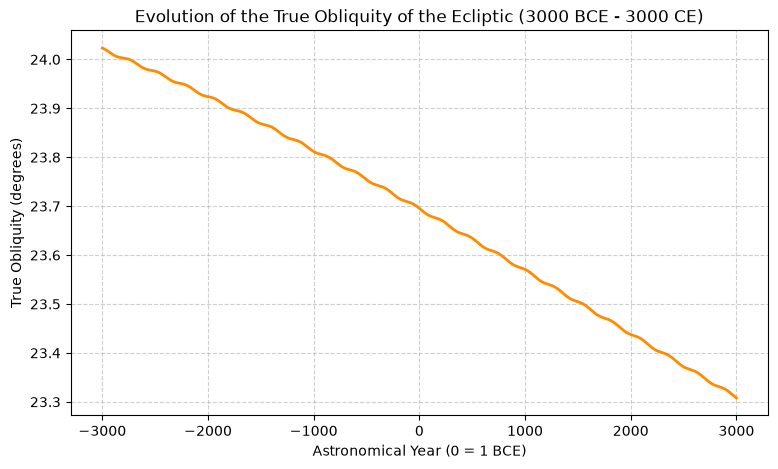

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Astronomical year range: from -3000 (3001 BCE) to +3000 (3000 CE), every 20 years
years = np.arange(-3000, 3001, 20)

# Calculate true obliquity for January 1st of each year
obliquities = []
for y in years:
    mtime = mn.Time(f"{y:04d}-01-01 12:00:00", calendar='proleptic')
    eps = mn.Astro.true_obliquity(mtime)
    obliquities.append(eps)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(years, obliquities, color='darkorange', lw=2)
ax.set_title("Evolution of the True Obliquity of the Ecliptic (3000 BCE - 3000 CE)")
ax.set_xlabel("Astronomical Year (0 = 1 BCE)")
ax.set_ylabel("True Obliquity (degrees)")
ax.grid(True, ls='--', alpha=0.6)
plt.show()

### Equation of Time

The Equation of Time describes the discrepancy between apparent solar time (sundial time) and mean solar time (clock time). Using the `Astro` class, we can reproduce the classic Equation of Time curve.

In [48]:
import plotly.graph_objects as go
import pandas as pd

# Calculate the Equation of Time for every day of a standard year
dates = pd.date_range('2024-01-01', '2024-12-31', freq='D')
eot = []
hover_texts = []
for d in dates:
    mtime = mn.Time(str(d))
    # We now have a fixed implementation in montu.Astro
    val = mn.Astro.equation_of_time(mtime)
    eot.append(val)
    
    # Format custom hover text: 'Jun 21<br>3m 4s'
    sign = "-" if val < 0 else ""
    abs_val = abs(val)
    m = int(abs_val)
    s = int(round((abs_val - m) * 60))
    # Format date avoiding padded zeros (e.g., 'Jun 21')
    date_str = d.strftime('%b %-d')
    hover_texts.append(f"{date_str}<br>{sign}{m}m {s}s")

fig = go.Figure()

# Equation of Time line
fig.add_trace(go.Scatter(
    x=dates, y=eot,
    mode='lines',
    line=dict(color='firebrick', width=3),
    name='Equation of Time',
    text=hover_texts,
    hoverinfo='text'
))

# Horizontal zero line
fig.add_hline(y=0, line_dash="solid", line_color="navy", line_width=1.5)

# Annotations for 'WATCH FASTER' and 'WATCH SLOWER'
fig.add_annotation(
    x=pd.Timestamp('2024-05-15'), y=17,
    text="WATCH FASTER",
    showarrow=False,
    font=dict(size=18, color="firebrick"),
    bgcolor="white"
)
fig.add_annotation(
    x=pd.Timestamp('2024-05-15'), y=-13,
    text="WATCH SLOWER",
    showarrow=False,
    font=dict(size=18, color="firebrick"),
    bgcolor="white"
)

# Customize Layout to match the classic chart style
fig.update_layout(
    title="Equation of Time",
    xaxis=dict(
        tickformat="%b",
        dtick="M1",
        gridcolor="navy",
        showgrid=True,
        mirror=True,
        ticks="outside",
        showline=True,
        linecolor="navy"
    ),
    yaxis=dict(
        title=dict(text="MINUTE", font=dict(color="firebrick")),
        tickfont=dict(color='firebrick'),
        range=[-20, 20],
        dtick=5,
        gridcolor="navy",
        showgrid=True,
        mirror=True,
        ticks="outside",
        showline=True,
        linecolor="navy"
    ),
    plot_bgcolor='white',
    width=800,
    height=500,
    margin=dict(l=60, r=40, t=60, b=40)
)

fig.show()

### Effect of the horizon on rising and setting times

When we calculate the rise and set of celestial bodies, by default they are computed with respect to the mathematical horizon (0 degrees). By using `horizon=True` in `conditions_in_sky`, we can include the actual topographical horizon. Here is an example of the Sun rising over the Royal Wadi of Akhet-aten (Amarna).

In [56]:
site = mn.Observer(
    site='amarna', 
    horizon_profile=dict(
        max_dist=50,
        az_step=0.5, # degrees
        coarse_step=0.1, # km
    )
)
sun = mn.Sun()
mtime = mn.Time('bce1341-10-21')

# Without horizon
sun.conditions_in_sky(at=mtime, observer=site, horizon=False)
rise_time = site.get_local_time(sun.condition.rise_time)
rise_az = sun.condition.rise_az

# With horizon
sun.conditions_in_sky(at=mtime, observer=site, horizon=True)
rise_time_hor = site.get_local_time(sun.condition.rise_time_hor)
rise_az_hor = sun.condition.rise_az_hor

print(f'Sunrise (mathematical): {rise_time} at azimuth {rise_az:.2f}°')
print(f'Sunrise (topographical): {rise_time_hor} at azimuth {rise_az_hor:.2f}°')

Obtaining horizon profile...
Sunrise (mathematical): 06:10:12.448 at azimuth 102.30°
Sunrise (topographical): 06:15:42.721 at azimuth 102.94°


It is a good idea that after using Horizons, clean your caches of DEM files:

In [50]:
mn.Horizon.clean_cache(verbose=True)

Successfully cleaned 5 DEM cache file(s) from /var/folders/xn/75ncx53144919w099wx5x5mw0000gn/T/montu_dem.


---
*Powered by MontuPython*. For more examples see [MontuPython GitHub repo](https://github.com/seap-udea/MontuPython/tree/main/examples).

[Jorge I. Zuluaga](https://jorgezuluaga.github.io) © 2023-present